# Step 1: Dataset Download and Extraction

In [ ]:
import os
import zipfile
import urllib.request
from google.colab import drive

# Mount Google Drive for persistent storage
drive.mount('/content/drive', force_remount=True)

# Define project directory paths within Google Drive
project_dir = "/content/drive/MyDrive/Brain_Tumor_Classification"
os.makedirs(project_dir, exist_ok=True)
%cd {project_dir}

# URL for the official stable repository of the brain tumor dataset
url = "https://github.com/sartajbhuvaji/Brain-Tumor-Classification-DataSet/archive/refs/heads/master.zip"
zip_path = "brain_tumor_dataset.zip"

# Download the dataset zip file if it does not already exist
if not os.path.exists(zip_path):
    print(" Downloading the brain tumor dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("✅ Download completed.")

# Extract the archive into a dedicated directory
extract_dir = "dataset_extracted"
if not os.path.exists(extract_dir):
    print(" Extracting image files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(" Extraction completed successfully!")
else:
    print("✅ Extracted dataset already exists.")

Mounted at /content/drive
/content/drive/MyDrive/Brain_Tumor_Classification
✅ Extracted dataset already exists.


# Step 2: Data Distribution and Image Metadata Analysis

In [2]:
import cv2

# Set the path to the training directory
train_dir = "dataset_extracted/Brain-Tumor-Classification-DataSet-master/Training"

# Retrieve target class names based on directory structure
classes = os.listdir(train_dir)
print(f" Discovered Classes: {classes}\n")

# Iterate through each class folder to verify dataset balance and dimensions
for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    if os.path.isdir(cls_path):
        # Filter and count valid image files (PNG, JPG, JPEG)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f" Class [{cls}]: Contains {len(images)} images.")

        # Analyze spatial dimensions and color channels of a sample image
        if len(images) > 0:
            sample_img_path = os.path.join(cls_path, images[0])
            sample_img = cv2.imread(sample_img_path)
            # Shapes are represented as (Height, Width, Channels)
            print(f"    Sample Image Shape: {sample_img.shape}")

 Discovered Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

 Class [glioma_tumor]: Contains 826 images.
    Sample Image Shape: (512, 512, 3)
 Class [meningioma_tumor]: Contains 822 images.
    Sample Image Shape: (512, 512, 3)
 Class [no_tumor]: Contains 395 images.
    Sample Image Shape: (350, 350, 3)
 Class [pituitary_tumor]: Contains 827 images.
    Sample Image Shape: (512, 512, 3)


# Step 3: Data Visualization and Quality Control

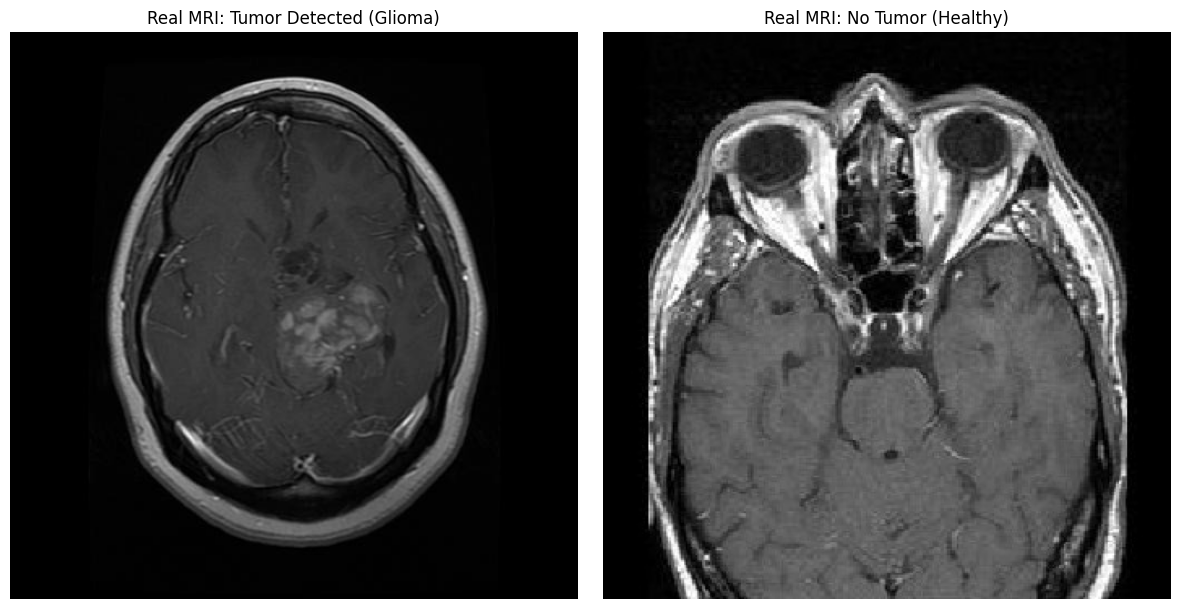


 Step 1 pipeline executed successfully.Visual assets saved.


In [3]:
import matplotlib.pyplot as plt

# Define absolute paths for pathological vs. healthy examples
tumor_dir = os.path.join(train_dir, 'glioma_tumor')
healthy_dir = os.path.join(train_dir, 'no_tumor')

# Fetch the first available filename from each respective category
tumor_img_name = [f for f in os.listdir(tumor_dir) if f.lower().endswith(('.png', '.jpg'))][0]
healthy_img_name = [f for f in os.listdir(healthy_dir) if f.lower().endswith(('.png', '.jpg'))][0]

# Load images using OpenCV
tumor_img = cv2.imread(os.path.join(tumor_dir, tumor_img_name))
healthy_img = cv2.imread(os.path.join(healthy_dir, healthy_img_name))

# Initialize a side-by-side subplot canvas for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Render pathological MRI scan (Convert BGR to RGB for correct color mapping)
axes[0].imshow(cv2.cvtColor(tumor_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Real MRI: Tumor Detected (Glioma)")
axes[0].axis('off')

# Render healthy control MRI scan
axes[1].imshow(cv2.cvtColor(healthy_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Real MRI: No Tumor (Healthy)")
axes[1].axis('off')

plt.tight_layout()

# Save the plot locally
plt.savefig("01_exploration_output.png", bbox_inches='tight', dpi=100)
plt.show()

print("\n Step 1 pipeline executed successfully. Visual assets saved.")